In [1]:
import numpy as np
import pandas as pd
from astroquery.gaia import Gaia
from astroquery.simbad import Simbad
import matplotlib.pyplot as plt
from astropy.table import Column, join, Table, vstack, hstack
from astropy.io import ascii
from HMXB_pipeline_class import pipeline
import astropy.coordinates as coords
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.visualization import astropy_mpl_style
import corner
from datetime import datetime
import os
from astropy.io.votable import parse
import emcee

In [2]:
from Galactic_traceback import GalacticTraceback
from Galactic_traceback_for_MCMC import galactic_path_MCMC as gpMCMC

/home/karan/Documents/UvA/Thesis/Code/Galactic_traceback_for_MCMC.py:395: SyntaxWarning: invalid escape sequence '\p'
  linestyle='--',linewidth=3.0,label=f'Cluster age {age_median:.2f} $\pm$ {age_std:.2f} Myr')


In [3]:
cwd = os.getcwd()
cwd
home_files = os.path.dirname(cwd)
home_files = home_files + '/'
csv_files  = home_files + 'DATA/'
csv_files

'/home/karan/Documents/UvA/Thesis/DATA/'

In [4]:
HMXB_table = ascii.read(csv_files+'HMXB_20250602_.ecsv',format='ecsv')

In [5]:
HMXB_table['Name']

X Per
EXO 051910+3737.7
RX J0440.9+4431
XTE J0421+560
EM* AS 14
gam Cas
IGR J00370+6122
V 0332+53
Swift J0243.6+6124
LS I+61 303
RX J0146.9+6121


# Names
177037


In [6]:
star_170037 = HMXB_table[HMXB_table['Name'] == '4U 1700-377']
star_170037['RV'] = -64.5
star_170037

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,parallax,parallax_error,radial_velocity,radial_velocity_error,phot_g_mean_mag,l,b,ruwe,distance_bj,distance_bj_low,distance_bj_high,Name,Mx,Mx_err,Mo,Mo_err,RV,RV_err,Period,Period_err,Spin_period,Spin_period_err,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,SpType,Mod_SpType,SpColor,pm_l_err,pm_b_err,l_err,b_err,V_pec_tan_err,V_pec_3d_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,mas,mas,km / s,km / s,mag,deg,deg,,kpc,kpc,kpc,,,,,,km / s,km / s,,,,,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,,,,,km / s,km / s
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32,float64,float64,float32,float64,float64,float64,str23,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str21,str17,str10,float64,float64,float64,float64,float64,float64
5976382915813535232,255.9865659301791,0.021049444,-37.8441202722809,0.012138224,2.4137032635492046,0.02806476,5.021949969731823,0.021347089,0.6327358617075665,0.025948899,--,--,6.4204698,347.75444710988126,2.173492429913019,0.8081919,1.5139931999999998,1.4613417,1.5923752,4U 1700-377,1.96,0.19,46.0,5.0,-64.5,10.0,3.41166,4e-06,--,--,1.5804383163952436,5.463046443844808,1.095932705667702,6.679230942389423,237.63301645326374,-11.43675757800189,-2.171203317603579,-1.0177427454204167,-7.952405001432037,-0.1525239568062298,0.060484562036866286,-9.372852158968954,57.79035653375137,-42.674742839599006,7.786773718254618,2.0531908890512525,71.83911876355393,0.06481477741223182,O6Iafcp,xkcd:blue,xkcd:blue,0.0240715261860172,0.012151228689122667,0.015476749868062746,0.006993492825535058,14.863580024906693,25.05500664499122


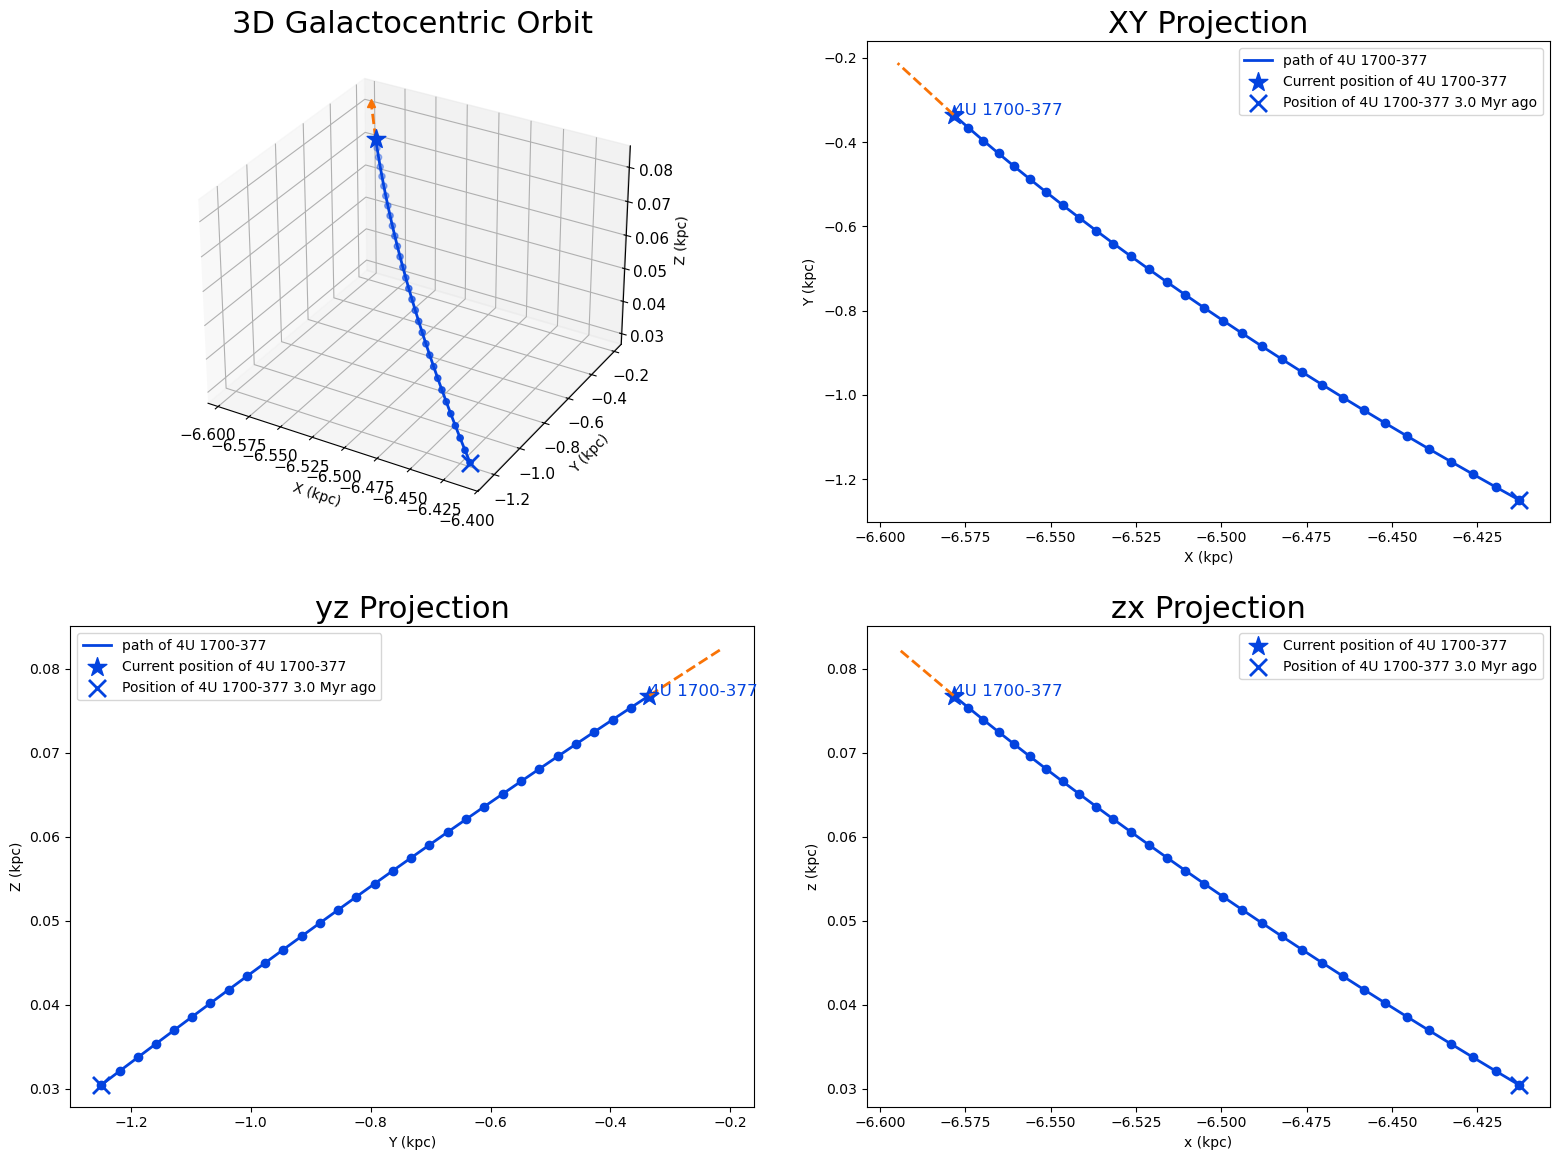

In [7]:
GalacticTraceback(star_170037,int_time=-3.0).plot_in_galactocentric(star_170037,cluster=None,figname=None,savefig=False)

# Match with NGC 6231

In [8]:
ngc6231 = ascii.read(csv_files+'NGC2631_param.ecsv',format='ecsv')
ngc6231

Name,distance_bj,l,b,pm_l_poleski,pm_b_poleski,ra,dec,pmra,pmra_err,pmdec,pmdec_error,parallax,parallax_error,RV
,kpc,deg,deg,mas / yr,mas / yr,deg,deg,mas / yr,mas / yr,mas / yr,mas / yr,mas,mas,km / s
str8,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
NGC 6231,1.55,343.4762,1.17,-2.0141207,-0.94955287,253.542202,-41.8245107,-0.529,0.007,-2.177,0.007,0.589,0.002,-25.0


In [9]:
ngc6231_members =ascii.read(csv_files+'Ngc6231_members_galacitc.ecsv', format='ecsv')

In [10]:
ngc6231_members

TYPED_ID,MATCHING_ID,ANG_DIST,MAIN_ID,OTYPE_S,ra,dec,COO_ERR_MAJA_d,COO_ERR_MINA_d,COO_ERR_ANGLE_d,PMRA,PMDEC,PM_ERR_MAJA,PM_ERR_MINA,PM_ERR_ANGLE,PLX_VALUE,RV_VALUE,Z_VALUE,VLSR,GALDIM_MAJAXIS,GALDIM_MINAXIS,GALDIM_ANGLE,SP_TYPE,MORPH_TYPE,NB_REF,FILTER_NAME_U,FLUX_U,FLUX_ERROR_U,FLUX_SYSTEM_U,FLUX_BIBCODE_U,FLUX_VAR_U,FLUX_MULT_U,FLUX_QUAL_U,FLUX_UNIT_U,FILTER_NAME_B,FLUX_B,FLUX_ERROR_B,FLUX_SYSTEM_B,FLUX_BIBCODE_B,FLUX_VAR_B,FLUX_MULT_B,FLUX_QUAL_B,FLUX_UNIT_B,FILTER_NAME_V,FLUX_V,FLUX_ERROR_V,FLUX_SYSTEM_V,FLUX_BIBCODE_V,FLUX_VAR_V,FLUX_MULT_V,FLUX_QUAL_V,FLUX_UNIT_V,FILTER_NAME_G,FLUX_G,FLUX_ERROR_G,FLUX_SYSTEM_G,FLUX_BIBCODE_G,FLUX_VAR_G,FLUX_MULT_G,FLUX_QUAL_G,FLUX_UNIT_G,FILTER_NAME_R,FLUX_R,FLUX_ERROR_R,FLUX_SYSTEM_R,FLUX_BIBCODE_R,FLUX_VAR_R,FLUX_MULT_R,FLUX_QUAL_R,FLUX_UNIT_R,FILTER_NAME_I,FLUX_I,FLUX_ERROR_I,FLUX_SYSTEM_I,FLUX_BIBCODE_I,FLUX_VAR_I,FLUX_MULT_I,FLUX_QUAL_I,FLUX_UNIT_I,FILTER_NAME_J,FLUX_J,FLUX_ERROR_J,FLUX_SYSTEM_J,FLUX_BIBCODE_J,FLUX_VAR_J,FLUX_MULT_J,FLUX_QUAL_J,FLUX_UNIT_J,FILTER_NAME_H,FLUX_H,FLUX_ERROR_H,FLUX_SYSTEM_H,FLUX_BIBCODE_H,FLUX_VAR_H,FLUX_MULT_H,FLUX_QUAL_H,FLUX_UNIT_H,FILTER_NAME_K,FLUX_K,FLUX_ERROR_K,FLUX_SYSTEM_K,FLUX_BIBCODE_K,FLUX_VAR_K,FLUX_MULT_K,FLUX_QUAL_K,FLUX_UNIT_K,FILTER_NAME_u,FLUX_u,FLUX_ERROR_u,FLUX_SYSTEM_u,FLUX_BIBCODE_u,FLUX_VAR_u,FLUX_MULT_u,FLUX_QUAL_u,FLUX_UNIT_u,FILTER_NAME_g,FLUX_g,FLUX_ERROR_g,FLUX_SYSTEM_g,FLUX_BIBCODE_g,FLUX_VAR_g,FLUX_MULT_g,FLUX_QUAL_g,FLUX_UNIT_g,FILTER_NAME_r,FLUX_r,FLUX_ERROR_r,FLUX_SYSTEM_r,FLUX_BIBCODE_r,FLUX_VAR_r,FLUX_MULT_r,FLUX_QUAL_r,FLUX_UNIT_r,FILTER_NAME_i,FLUX_i,FLUX_ERROR_i,FLUX_SYSTEM_i,FLUX_BIBCODE_i,FLUX_VAR_i,FLUX_MULT_i,FLUX_QUAL_i,FLUX_UNIT_i,FILTER_NAME_z,FLUX_z,FLUX_ERROR_z,FLUX_SYSTEM_z,FLUX_BIBCODE_z,FLUX_VAR_z,FLUX_MULT_z,FLUX_QUAL_z,FLUX_UNIT_z,Diameter_diameter,Diameter_Q,Diameter_unit,Diameter_error,Diameter_filter,Diameter_method,Diameter_bibcode,Distance_distance,Distance_Q,Distance_unit,Distance_merr,Distance_perr,Distance_method,Distance_bibcode,Fe_H_Teff,Fe_H_log_g,Fe_H_Fe_H,Fe_H_flag,Fe_H_CompStar,Fe_H_CatNo,Fe_H_bibcode,Herschel_ObsId,Herschel_alpha,Herschel_delta,PLX_plx,PLX_me,PLX_R,PLX_bibcode,PM_pmra,PM_me_pmra,PM_pmde,PM_me_pmde,PM_system,PM_bibcode,ROT_upVsini,ROT_Vsini,ROT_err,ROT_mes,ROT_qual,ROT_bibcode,V__vartyp,V__Lomax,V__max,V__R_max,V__band,V__Upmin,V__min,V__R_min,V__UpPeriod,V__period,V__R_period,V__epoch,V__R_epoch,V__D_rt,V__R_D_rt,V__bibcode,velocities_type,velocities_Value,velocities_R,velocities_me,velocities_Acc,velocities_Nmes,velocities_nat,velocities_Q,velocities_dom,velocities_res,velocities_d,velocities_Date,velocities_Rem,velocities_Origin,velocities_bibcode,ISO_TDT,ISO_alpha,ISO_delta,IUE_Homogenized_Name,IUE_ComplID,IUE_PROG,IUE_CL,IUE_D,IUE_CAM,IUE_IMAGE,IUE_A,IUE_FES,IUE_MD,IUE_ObsDate,IUE_Time,IUE_ExpTim,IUE_m,IUE_CEB,IUE_S,IUE_Comments,IUE_F,IUE_bibcode,XMM_Obsno,OID4,l,b
,,arcsec,,,deg,deg,mas,mas,deg,mas / yr,mas / yr,mas / yr,mas / yr,deg,mas,km / s,,km / s,arcmin,arcmin,deg,,,,,mag,,,,,,,,,mag,,,,,,,,,mag,,,,,,,,,mag,,,,,,,,,mag,,,,,,,,,mag,,,,,,,,,mag,,,,,,,,,mag,,,,,,,,,mag,,,,,,,,,mag,,,,,,,,,mag,,,,,,,,,mag,,,,,,,,,mag,,,,,,,,,mag,,,,,,,,,,,,,,,,,,,,,,unit-degK,cm / s2,,,,,,,h:m:s,d:m:s,mas,mas,,,mas / yr,mas / yr,mas / yr,mas / yr,,,,km / s,,,,,,,mag,,,,mag,,,d,,d,,,,,,,,,,,,,,,,,,,,,deg,deg,,,,,,,,,,,,,s,,,,,,,,,deg,deg
object,object,float32,object,object,float64,float64,float32,float32,int16,float64,float64,float32,float32,int16,float64,float64,float64,float64,float32,float32,int16,object,object,int32,object,float32,float32,object,object,str1,object,str1,str1,object,float32,float32,object,object,str1,object,str1,str1,object,float32,float32,object,object,str1,object,str1,str1,object,float32,float32,object,object,str1,object,str1,str1,object,float32,float32,object,object,str1,object,str1,str1,object,float32,float32,object,object,str1,object,str1,str1,object,float32,float32,object,object,str1,object,str1,str1,object,float32,float32,object,object,str1,object,str1,s

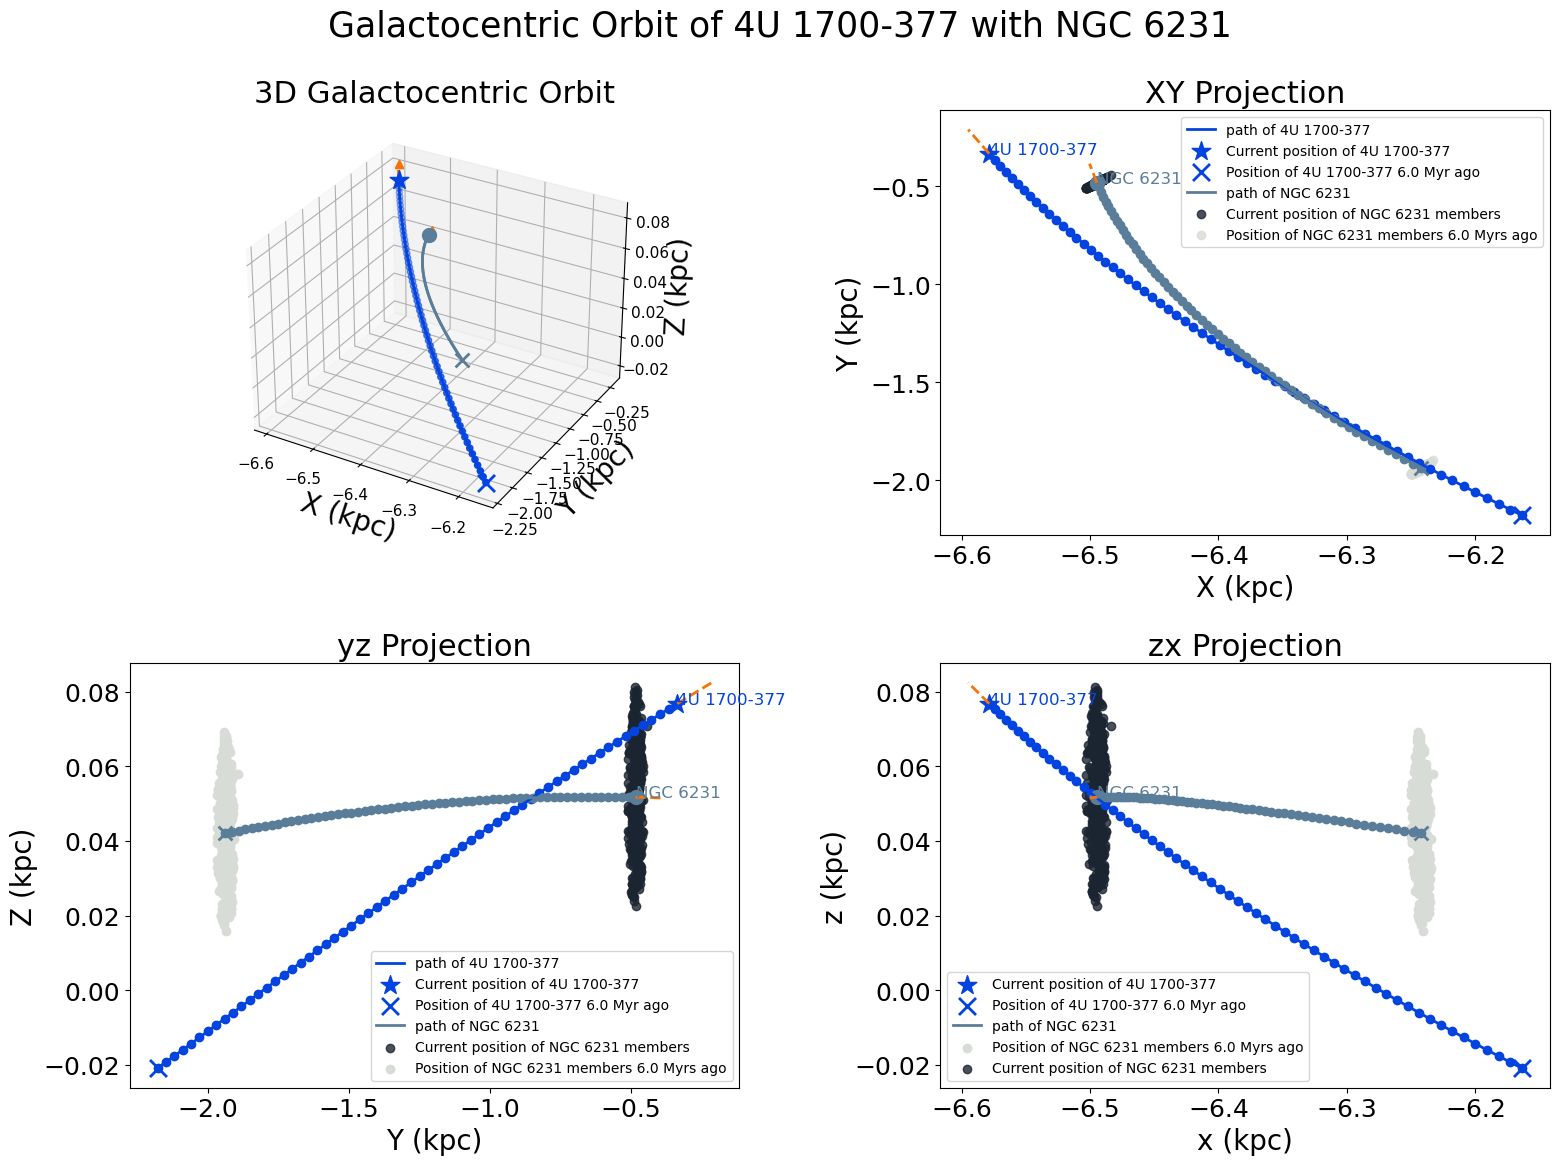

In [11]:
GalacticTraceback(star_170037,int_time=-6.0).plot_in_galactocentric(star_170037,cluster=ngc6231,cluster_members=ngc6231_members,figname=None,savefig=False)

In [12]:
ngc_radii, ngc_radius, std_radius =GalacticTraceback(None,None).calc_cluster_radius(ngc6231_members,ngc6231)
ngc_radii.value

array([0.02355347, 0.01891561, 0.01425483, ..., 0.02829888, 0.02864854,
       0.02877626])

relative velocity 68.94428682729693 km / s, std 0.3190598480554168 km / s
22.9756086975755 pc
-2.4000000000000007e-06 Myr ago


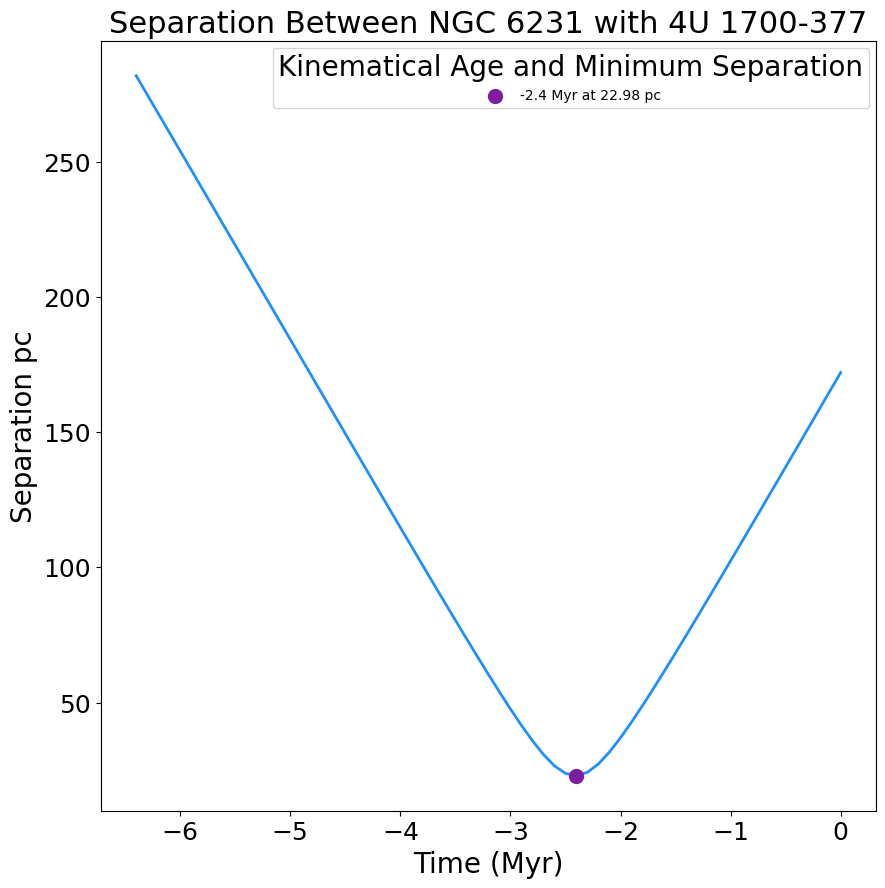

In [13]:
GalacticTraceback(star_170037,int_time=-6.4).plot_separation(star_170037,cluster=ngc6231,savefig=False)

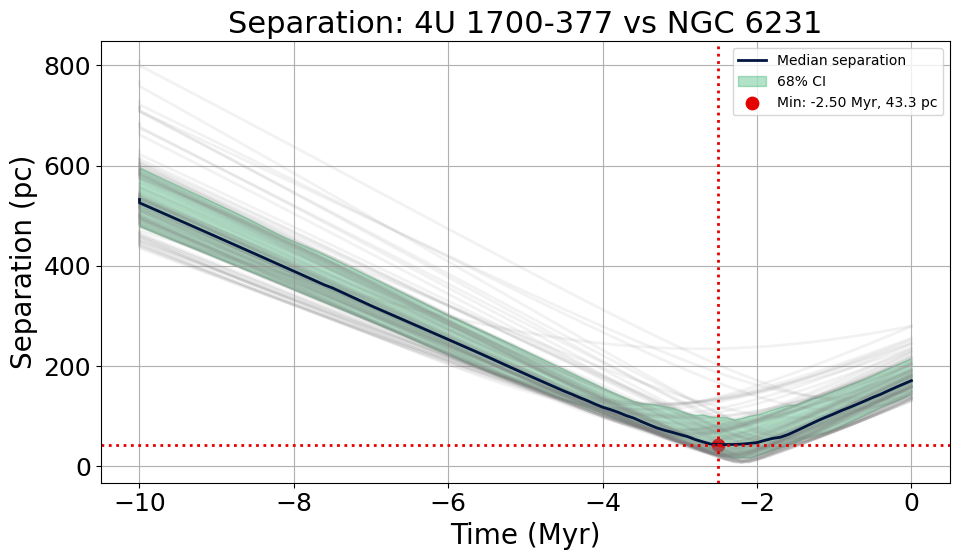

In [14]:
GalacticTraceback(star_170037,int_time=-10.0).plot_separation_with_uncertainty(star_170037,cluster=ngc6231,savefig=False)

In [15]:
names_x = ['1700-377','NGC 6231']
gpmc_args = {'backend_name':'1700377_ngc6231_chain','star_params':star_170037,'cluster_params':ngc6231, 'cluster_radius':None,'int_time':-10.0,
            'names':names_x}

In [16]:
#sample_170037, state_170037 = gpMCMC().start_mcmc(**gpmc_args)

In [19]:
backend_170037 = emcee.backends.HDFBackend('1700377_ngc6231_chain.h5')
#backend_170037.get_autocorr_time()

In [20]:
chain_170037 = backend_170037.get_chain(thin=10, flat=True)
blobs_170037 = backend_170037.get_blobs(thin=10,flat=True)
kinematic_ages = np.array([b[0] for b in blobs_170037])
min_separations = np.array([b[1] for b in blobs_170037])

In [21]:
len(backend_170037.get_chain(flat=True))

24000

In [22]:
10**7.14/(1e6)

13.803842646028839

In [23]:
cluster_age = np.array([4.7,0.4])
cluster_age[0]

np.float64(4.7)

In [24]:
separation_dictionary = {'flat_chain':backend_170037.get_chain(flat=True),
                        'cluster_params':ngc6231,
                        'int_time':-6.0,
                        'star_ra':star_170037['ra'],
                        'star_dec':star_170037['dec'],
                        'cluster_radius':ngc_radii.value,
                        'title':'4U 1700-377 with NGC 6231',
                        'n_samples':1000,
                        'cluster_age':cluster_age,
                        'savefig':True,
                        'ylim':500}

-5.1000000000000005 -4.3


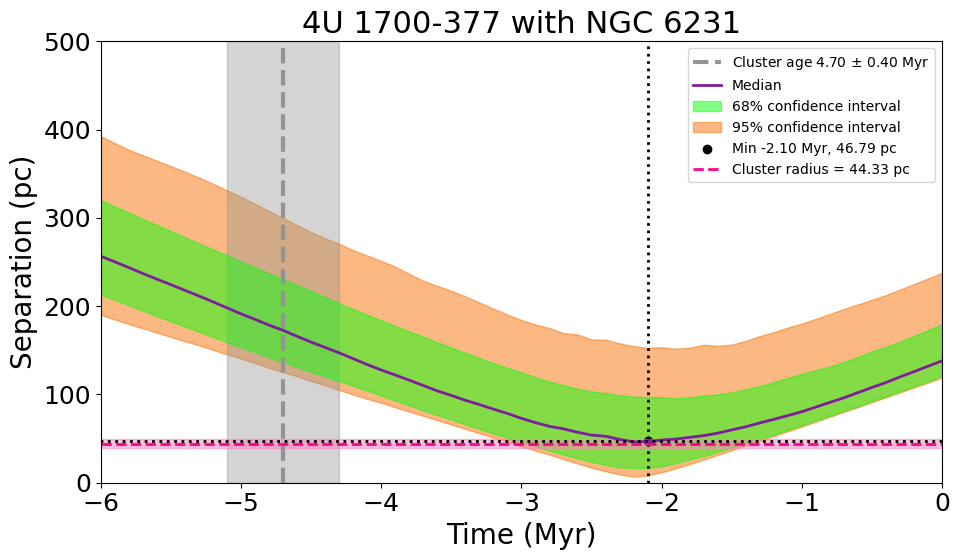

In [25]:
gpMCMC().compute_full_separations_and_plot(**separation_dictionary)

2400
[[1.5]
 [1.7]
 [1.5]
 ...
 [1.6]
 [1.5]
 [2.7]]


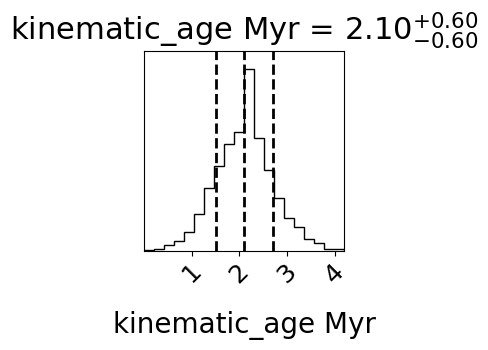

In [26]:
blobs_2d = kinematic_ages[:, None]  # reshape to (n_samples, 1)
print(len(blobs_2d))
print(blobs_2d)
fig = corner.corner(blobs_2d, labels=["kinematic_age Myr"],quantiles=(0.16,0.5, 0.84),show_titles=True,use_math_text=True,fill_contours=True)
plt.savefig('/home/karan/Documents/UvA/Thesis/Figures/MCMC/'+'kinage_170037_ngc6231',dpi=300)
plt.show()

In [27]:
star_2206_76 = HMXB_table[HMXB_table['source_id'] == 2005653524280214400]

In [28]:
star_2206_76

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,parallax,parallax_error,radial_velocity,radial_velocity_error,phot_g_mean_mag,l,b,ruwe,distance_bj,distance_bj_low,distance_bj_high,Name,Mx,Mx_err,Mo,Mo_err,RV,RV_err,Period,Period_err,Spin_period,Spin_period_err,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,SpType,Mod_SpType,SpColor,pm_l_err,pm_b_err,l_err,b_err,V_pec_tan_err,V_pec_3d_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,mas,mas,km / s,km / s,mag,deg,deg,,kpc,kpc,kpc,,,,,,km / s,km / s,,,,,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,,,,,km / s,km / s
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32,float64,float64,float32,float64,float64,float64,str23,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str21,str17,str10,float64,float64,float64,float64,float64,float64
2005653524280214400,331.98428755192987,0.012050482,54.518432170802825,0.011263556,-4.172517978480273,0.0151939755,-3.316562372366748,0.013615789,0.3050532500378427,0.013605253,--,--,9.743357,100.60324189142595,-1.1059224650682717,0.9785323,3.1674092000000003,3.0472979000000002,3.3326724,4U 2206+543,--,--,18.0,--,-54.5,1.0,9.558,0.04,392.0,--,3.2781161973391435,-5.320924798903758,-0.31185178362654387,9.27089679752768,240.70091275872343,-23.97988925926849,0.8737514207648808,-0.5207464477558823,-11.231698001733578,-5.1783237426971525,-0.03083334516427316,-27.277923747094576,15.677751490132476,-15.990378251171846,-1.0163524769714867,0.2397280092936116,22.393840412084316,0.14620267017950472,O9.5IIIe,xkcd:bright blue,xkcd:blue,0.01469354835801458,0.007325491365767859,0.011726550513661987,0.005989686069167577,8.273596263845704,11.971901069446087


In [29]:
star_2206_76['RV'] = -73.6
star_2206_76['RV_err'] = 9.4

In [30]:
GalacticTraceback(star_2206_76,int_time=-30.0).plot_in_galactocentric(star_2206_76,cluster=cep_ob1_params,cluster_members=cep_ob1_members,figname=None,savefig=False)

NameError: name 'cep_ob1_params' is not defined

In [ ]:
GalacticTraceback(star_2206_76,int_time=-30.0).plot_separation_with_uncertainty(star_2206,cluster=cep_ob1_params,savefig=False)

In [ ]:
names_x = ['4U 2206_543','CEP OB1']
gpmc_args_ham = {'backend_name':'4U2206_Cepob1_chain_WITH_HAMBARYAN','star_params':star_2206_76,'cluster_params':cep_ob1_params, 'cluster_radius':None,'int_time':-30.0,
            'names':names_x}

In [ ]:
print(star_2206_76['RV'])

In [ ]:
#sample_2206, state_2206 = gpMCMC().start_mcmc(**gpmc_args_ham)

In [ ]:
backend_2206_ham = emcee.backends.HDFBackend('4U2206_Cepob1_chain_WITH_HAMBARYAN.h5')

In [ ]:
chain_2206_ham = backend_2206_ham.get_chain(thin=10, flat=True)
blobs_2206_ham = backend_2206_ham.get_blobs(thin=10,flat=True)
kinematic_ages_ham = np.array([b[0] for b in blobs_2206_ham])
min_separations_ham = np.array([b[1] for b in blobs_2206_ham])

In [ ]:
#gpMCMC().compute_full_separations_and_plot(flat_chain=chain_2206_ham, cluster_params=cep_ob1_params, int_time=-20.0, star_ra=star_2206['ra'], 
                                  # star_dec=star_2206['dec'],
                                  # cluster_radius=None, title='4U2206+543 with CepOb1',
                                  # n_samples=2000,savefig=True)